## 1 - Loading and Inspecting

In [1]:
import pandas as pd
import numpy as np
from sklearn import decomposition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import altair as alt

df = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/processed/matrix.csv')

# Fix the sample column anme if it loaded as unnamed
if 'Unnamed:0' in df.columns:
    df.rename(columns={'Unnamed: 0':'Sample'}, inplace=True)

print(f'Loaded matrix: {df.shape[0]} samples x {df.shape[1]} columns')
df.head(3)

Loaded matrix: 1092 samples x 4945 columns


,Sample,rs144366698,rs200391621,rs78888200,rs200049935,rs182808734,rs147783986,rs202082800,rs185745570,rs151231161,...,rs6010062,rs186386126,rs73174436,rs6010073,rs181024981,rs180882000,rs147614277,rs192355741,rs191731586,Population code
0,HG00096,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,GBR
1,HG00097,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,GBR
2,HG00099,0,0,1,0,0,1,0,0,0,...,1,0,0,2,0,0,1,0,0,GBR


## 2 - Separating Genotypes From Metadata

In [2]:
# The non-SNP columns are metadata, not genetic data
non_snp_cols = ['Sample', 'Population code']

# Drop them to get the pure numeric matrix
df_snps = df.drop(columns=non_snp_cols)

# Convert to numpy for scikit-learn
matrix = df_snps.to_numpy()
print(f'SNP matrix shape (samples x variants): {matrix.shape}')


SNP matrix shape (samples x variants): (1092, 4943)


## 3 - Running PCA

In [3]:
# Fit PCA, asking for 2 components (PC1 and PC2)
pca = decomposition.PCA(n_components=2)
pca.fit(matrix)

# How much variance does each component explain?
print('Variance explained:')
print(f' PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f' PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')

# Project every sample into PC space
to_plot = pca.transform(matrix)
print(f'Projected shape: {to_plot.shape}') 


Variance explained:
 PC1: 8.25%
 PC2: 5.41%
Projected shape: (1092, 2)


## 4 - Quick Sanity-Check Scatter

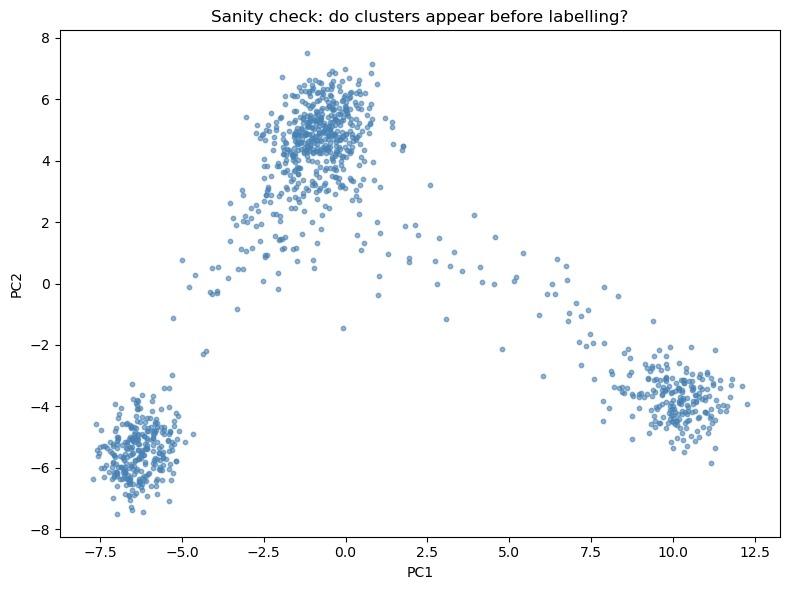

In [4]:
# Plain scatter before adding labels - just to verify clustering
plt.figure(figsize=(8,6))
plt.scatter(to_plot[:,0], to_plot[:,1], s=10, alpha=0.6, color='steelblue')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Sanity check: do clusters appear before labelling?')
plt.tight_layout()
plt.savefig('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_unlabelled.png', dpi=150)
plt.show()

## 5 - Building the Plotting DataFrame With Labels

In [5]:
# Small DataFrame: just metadata plus PC coordinates
df_plot = df[non_snp_cols].copy()
df_plot['PC1'] = to_plot[:, 0]
df_plot['PC2'] = to_plot[:, 1]

# Load population descriptions for super population names
pop = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/raw/igsr_populations.tsv', sep='\t')

# Merge on population code
df_plot = df_plot.merge(
    pop[['Population code', 'Superpopulation name', 'Population name']],
    on='Population code', how='left'
)

print(df_plot['Superpopulation name'].unique())
df_plot.head()

<StringArray>
[  'European Ancestry', 'East Asian Ancestry',   'American Ancestry',
    'African Ancestry']
Length: 4, dtype: str


,Sample,Population code,PC1,PC2,Superpopulation name,Population name
0,HG00096,GBR,0.312827,5.354349,European Ancestry,British
1,HG00097,GBR,-0.679403,6.183329,European Ancestry,British
2,HG00099,GBR,-0.420710,5.266720,European Ancestry,British
3,HG00100,GBR,-0.805419,5.965095,European Ancestry,British
4,HG00101,GBR,-0.771385,4.332076,European Ancestry,British


## 6 - The Headline Figure: PCA by Superpopulation

In [6]:
chart_super = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x=alt.X('PC1:Q', title='PC1'),
    y=alt.Y('PC2:Q', title='PC2'),
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10'),
        legend=alt.Legend(title='Superpopulation')),
    tooltip=['Sample:N', 'Population name:N', 'Superpopulation name:N']
).properties(
    title={'text': 'Human Population Structure — 1000 Genomes Chr 22',
           'subtitle': 'PCA of ~5,000 SNPs from 1,092 individuals'},
    width=600, height=450
).interactive()  # enables pan and zoom

chart_super.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.html')
chart_super

alt.Chart(...)

## 7 - PCA by Individual Population

In [7]:
chart_pop = alt.Chart(df_plot).mark_circle(size=35, opacity=0.70).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category20'),
        legend=alt.Legend(title='Population', columns=2)),
    tooltip=['Sample:N', 'Population code:N', 'Population name:N',
             'Superpopulation name:N']
).properties(title='Structure by individual population',
    width=650, height=480).interactive()

chart_pop.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_population_codes.html')
chart_pop

alt.Chart(...)

## 8 - t-SNE Comparison

In [8]:
# t-SNE for visual comparison only (~2-5 minutes to run)
print('Running t-SNE...')
X_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca', # pca init is more stable than random
    random_state=42, # fix the seed for reproducibility
    perplexity=30 # default -- do NOT tune to get a 'nicer' plot
).fit_transform(matrix)

df_plot['tsne1'] = X_tsne[:,0]
df_plot['tsne2'] = X_tsne[:,1]

chart_tsne = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x='tsne1:Q', y='tsne2:Q',
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(title='t-SNE (perplexity=30) — compare with PCA',
    width=580, height=430).interactive()
 
chart_tsne.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/tsne_superpopulation.html')
chart_tsne

Running t-SNE...


alt.Chart(...)

## Saving Static PNG

In [9]:
import vl_convert as vlc

# Convert the superpopulation chart to a static PNG
png_bytes = vlc.vegalite_to_png(chart_super.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.png', 'wb') as f:
    f.write(png_bytes)
print('PNG saved for README.')

PNG saved for README.


## 9 - Side-Quest: SNP-PCA

SNP matrix shape: (4943, 1092)


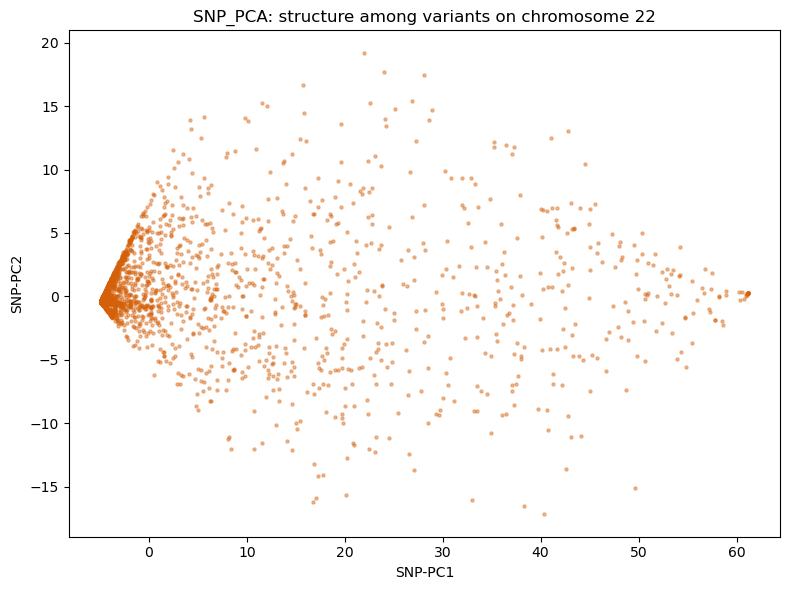

In [10]:
# Run PCA on the TRANSPOSED matrix (SNPs as rows)
matrix_T = matrix.T
print(f'SNP matrix shape: {matrix_T.shape}')

pca_snps = decomposition.PCA(n_components=2)
snp_coords = pca_snps.fit_transform(matrix_T)

plt.figure(figsize=(8,6))
plt.scatter(snp_coords[:, 0], snp_coords[:, 1],
            s=5, alpha=0.4, color='#D4600A')
plt.xlabel('SNP-PC1'); plt.ylabel('SNP-PC2')
plt.title('SNP_PCA: structure among variants on chromosome 22')
plt.tight_layout()
plt.savefig('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/snp_pca.png', dpi=150)
plt.show()

## 10 - Replicating Novembre er at. - European Subset

In [11]:
# Filter the plotting frame to Europeans only
eur_mask = df_plot['Superpopulation name'] == 'European Ancestry'
df_eur = df_plot[eur_mask].reset_index(drop=True)

# Extract the genotype rows for just the Europeans samples gotten
eur_samples = df_eur['Sample'].tolist()
eur_idx = [list(df['Sample']).index(s) for s in eur_samples]
matrix_eur = matrix[eur_idx, :]

# Run PCA on Europeans alone
pca_eur = decomposition.PCA(n_components=2)
eur_coords = pca_eur.fit_transform(matrix_eur)

print(f'European samples: {len(eur_samples)}')
print(f'PC1: {pca_eur.explained_variance_ratio_[0]*100:.3f}%, '
      f'PC2: {pca_eur.explained_variance_ratio_[1]*100:.3f}%')

European samples: 379
PC1: 1.463%, PC2: 1.313%


In [12]:
# Creating PCA Chart

df_eur = df_eur.copy()
df_eur['PC1'] = eur_coords[:, 0]
df_eur['PC2'] = eur_coords[:, 1]

chart_eur = alt.Chart(df_eur).mark_circle(size=50, opacity=0.8).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category20')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title={'text': 'Within-European PCA — replicating Novembre 2008',
           'subtitle': 'Does European genetic structure mirror geography?'},
    width=580, height=430).interactive()

chart_eur.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_european_only.html')
chart_eur

alt.Chart(...)

## 11 - Building Africa-Only PCA

In [13]:
# Filter to African samples
afr_mask = df_plot['Superpopulation name'] == 'African Ancestry'
df_afr = df_plot[afr_mask].reset_index(drop=True)
 
afr_samples = df_afr['Sample'].tolist()
afr_idx = [list(df['Sample']).index(s) for s in afr_samples]
matrix_afr = matrix[afr_idx, :] 
 
print(f'African samples: {len(afr_samples)}')
print(df_afr['Population code'].value_counts())
 
# Run PCA with 3 components to see deeper structure
pca_afr = decomposition.PCA(n_components=3)
afr_coords = pca_afr.fit_transform(matrix_afr)
for i in range(3):
    print(f'PC{i+1}: {pca_afr.explained_variance_ratio_[i]*100:.3f}%')

African samples: 246
Population code
LWK    97
YRI    88
ASW    61
Name: count, dtype: int64
PC1: 1.913%
PC2: 1.387%
PC3: 1.185%


In [14]:
# Creating PC1 v PC2 chart

df_afr = df_afr.copy()
df_afr['PC1'] = afr_coords[:, 0]
df_afr['PC2'] = afr_coords[:, 1]
df_afr['PC3'] = afr_coords[:, 2]
 
chart_afr = alt.Chart(df_afr).mark_circle(size=55, opacity=0.8).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10'),
        legend=alt.Legend(title='Population (Africa)')),
    tooltip=['Sample:N', 'Population name:N', 'Population code:N']
).properties(
    title={'text': 'Within-Africa PCA — 1000 Genomes AFR (PC1 v PC2)',
           'subtitle': 'YRI=Nigeria, LWK=Kenya, ASW=African-American'},
    width=600, height=450).interactive()
 
chart_afr.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc1v2.html')
chart_afr


alt.Chart(...)

In [15]:
# Creating PC2 v PC3 chart

chart_afr_pc2v3 = alt.Chart(df_afr).mark_circle(size=50, opacity=0.8).encode(
    x='PC2:Q', y='PC3:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title='Within-Africa PCA — PC2 vs PC3',
    width=580, height=430).interactive()

chart_afr_pc2v3.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc2v3.html')
chart_afr_pc2v3

alt.Chart(...)

In [16]:
# Creating PC1 v PC3 chart

chart_afr_pc1v3 = alt.Chart(df_afr).mark_circle(size=55, opacity=0.8).encode(
    x='PC1:Q', y='PC3:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(
    title='Within-Africa PCA — PC1 vs PC3',
    width=580, height=430).interactive()

chart_afr_pc1v3.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_africa_pc1v3.html')
chart_afr_pc1v3

alt.Chart(...)

#### PC3 Analysis
PC2 vs PC3 and PC1 vs PC3 plots confirm that PC3 carries no additional 
population separation signal beyond what PC1 and PC2 already show. 
The main within-Africa structure — admixture on PC1, West vs East Africa 
on PC2 — is fully captured in two dimensions.

## 12 - Diversity Comparison

In [17]:
# Compare within-group diversity: Africa vs Europe
# Higher std dev of allele counts = more genetic diversity
eur_diversity = np.std(matrix_eur, axis=0).mean()
afr_diversity = np.std(matrix_afr, axis=0).mean()

print('===DIVERSITY COMPARISON===')
print(f'European within-group variability: {eur_diversity:.4f}')
print(f'African within-group variability: {afr_diversity:.4f}')
print(f'Ratio (AFR / EUR): {afr_diversity/eur_diversity:.3f}x')

===DIVERSITY COMPARISON===
European within-group variability: 0.1367
African within-group variability: 0.1955
Ratio (AFR / EUR): 1.430x


In [28]:
# Create a Bar chart to display and compare African vs European within-group diversity

# Build a small dataframe for Altair
df_diversity = pd.DataFrame({
    'Population': ['European', 'African'],
    'Diversity': [eur_diversity, afr_diversity],
    'Description': [
        f'n≈{len(eur_samples)} samples',
        f'n≈{len(afr_samples)} samples'
    ]
})

chart_diversity = alt.Chart(df_diversity).mark_bar(
    cornerRadiusTopLeft=4,
    cornerRadiusTopRight=4
).encode(
    x=alt.X('Population:N',
        axis=alt.Axis(labelFontSize=13, titleFontSize=14),
        title=None),
    y=alt.Y('Diversity:Q',
        title='Mean allele-count std dev',
        scale=alt.Scale(zero=True),
        axis=alt.Axis(labelFontSize=11, titleFontSize=13)),
    color=alt.Color('Population:N',
        scale=alt.Scale(
            domain=['European', 'African'],
            range=['#1A3A5C', '#D4600A']),
        legend=None),
    tooltip=[
        alt.Tooltip('Population:N', title='Population'),
        alt.Tooltip('Diversity:Q', title='Diversity', format='.4f'),
        alt.Tooltip('Description:N', title='Samples')
    ]
).properties(
    title=alt.TitleParams(
        text='Within-Group Genetic Diversity',
        subtitle='Higher value = more genetic variation within the population',
        fontSize=16,
        subtitleFontSize=12,
        subtitleColor='gray'
    ),
    width=350,
    height=400
)

# Add a text label on top of each bar showing the actual value of the within-group variability
text = chart_diversity.mark_text(
    align='center',
    baseline='top',
    dy=8,
    fontSize=12,
    fontWeight='bold'
).encode(
    text=alt.Text('Diversity:Q', format='.4f'),
    color=alt.value('white')
)

final_chart = (chart_diversity + text)

final_chart.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/diversity_comparison.html')

# Save PNG for README
import vl_convert as vlc
png_bytes = vlc.vegalite_to_png(final_chart.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/diversity_comparison.png', 'wb') as f:
    f.write(png_bytes)

final_chart

alt.LayerChart(...)